# Análise exploratória dos dados reais

Este notebook lê o CSV limpo gerado pelo notebook `00_limpeza_dados` e produz gráficos de distribuição para cada variável do formulário.

O objetivo é caracterizar o perfil dos geradores de resíduos e identificar padrões gerais antes da etapa de clusterização.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Configuração de fonte para suporte a caracteres acentuados nos gráficos.
# Sem isso, o matplotlib pode renderizar acentos como "?" dependendo do
# backend e da fonte padrão do sistema.
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

%matplotlib inline

DOCS_DIR = Path("../docs")
DOCS_DIR.mkdir(exist_ok=True)

df = pd.read_csv("../dados/respostas_limpo.csv")
print(f"{df.shape[0]} respostas, {df.shape[1]} colunas")
df.head()

161 respostas, 19 colunas


,timestamp,tipo_gerador,tipo_atividade,bairro_cidade,tipos_residuo,residuos_organicos,especificacao_residuos,origem_residuo,frequencia_descarte,quantidade_gerada,destino_atual,custo_destinacao,potencial_reaproveitamento,caracteristica_residuo,tentativa_reutilizacao,melhor_solucao,num_pessoas,conscientizacao,interesse_aprender
0,25/02/2026 19:23:46,Pessoa física (residência),"Alimentação (restaurante, padaria, mercado, etc.)",Outro,"Orgânicos (restos de alimentos, cascas, bagaço...",Restos de comida,Resto de refeição,Consumo diário,Semanal,Menos de 10 kg por semana,Coleta pública comum,Não,Sim,Alto teor orgânico,Não,Compostagem,NaN,NaN,NaN
1,25/02/2026 19:28:58,Pessoa física (residência),Residencial,Chapecó (sem bairro),"Orgânicos (restos de alimentos, cascas, bagaço...",Cascas de frutas,Casca de banana,Consumo diário,Diária,Menos de 10 kg por semana,Coleta pública comum,Não,Sim,"Contém vitaminas, minerais e compostos nutritivos",Sim,Óleo vegetal,NaN,NaN,NaN
2,25/02/2026 19:29:42,Pessoa física (residência),Residencial,Xaxim,"Orgânicos (restos de alimentos, cascas, bagaço...",Restos de comida,Restos de comida sobrada e cascas de frutas,Consumo diário,Semanal,Menos de 10 kg por semana,Compostagem,Não,Sim,"Contém vitaminas, minerais e compostos nutritivos",Sim,Compostagem,NaN,NaN,NaN
3,25/02/2026 19:30:07,Pessoa física (residência),Residencial,Xaxim,"Orgânicos (restos de alimentos, cascas, bagaço...",Restos de comida,"Arroz, restos de carnes e massas não consumida...",Sobra de matéria-prima,Diária,10–50 kg por semana,Coleta pública comum,Não,Não,Alto teor orgânico,Sim,O descarte me parece o mais adequado para alim...,NaN,NaN,NaN
4,25/02/2026 19:30:13,Pessoa física (residência),"Alimentação (restaurante, padaria, mercado, etc.)",Outro,"Plástico, Metal",Restos de comida,"Semente, restos de alimento, cascas de vários ...",Consumo diário,Diária,Menos de 10 kg por semana,Compostagem,Não,Sim,Alto teor orgânico,Sim,Compostagem,NaN,NaN,NaN


### Funções auxiliares

`plotar_barras` padroniza a visualização em barras horizontais com paleta de cores fixa.

`contar_multiselect` trata colunas onde o respondente podia marcar mais de uma opção. O Google Forms armazena essas respostas como texto separado por vírgula (ex: `"Plástico, Metal"`). A função separa cada opção e conta individualmente.

In [2]:
CORES = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63", "#9C27B0",
         "#00BCD4", "#FF5722", "#795548", "#607D8B", "#CDDC39"]


def plotar_barras(contagens, titulo, xlabel, save_path=None):
    """Plota um gráfico de barras horizontais a partir de uma Series de contagens."""
    contagens = contagens.sort_values()
    cores = (CORES * ((len(contagens) // len(CORES)) + 1))[:len(contagens)]
    plt.figure(figsize=(9, max(3, len(contagens) * 0.45)))
    plt.barh(contagens.index, contagens.values, color=cores)
    plt.title(titulo, fontsize=13, fontweight="bold")
    plt.xlabel(xlabel)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()


def contar_multiselect(coluna):
    """Separa respostas multi-select (separadas por vírgula) e conta cada opção."""
    return (
        coluna.dropna()
        .str.split(",")
        .explode()
        .str.strip()
        .value_counts()
    )

## 1. Quem é o gerador?

Perfil dos respondentes: tipo de gerador (pessoa física, MEI, empresa, instituição), atividade exercida e localização geográfica.

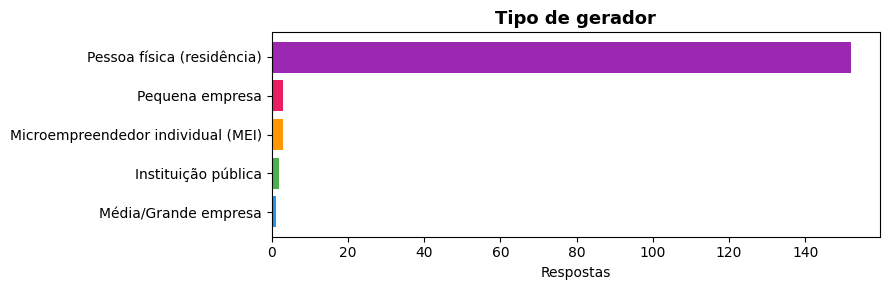

In [3]:
plotar_barras(df["tipo_gerador"].value_counts(), "Tipo de gerador", "Respostas", DOCS_DIR / "01_tipo_gerador.png")


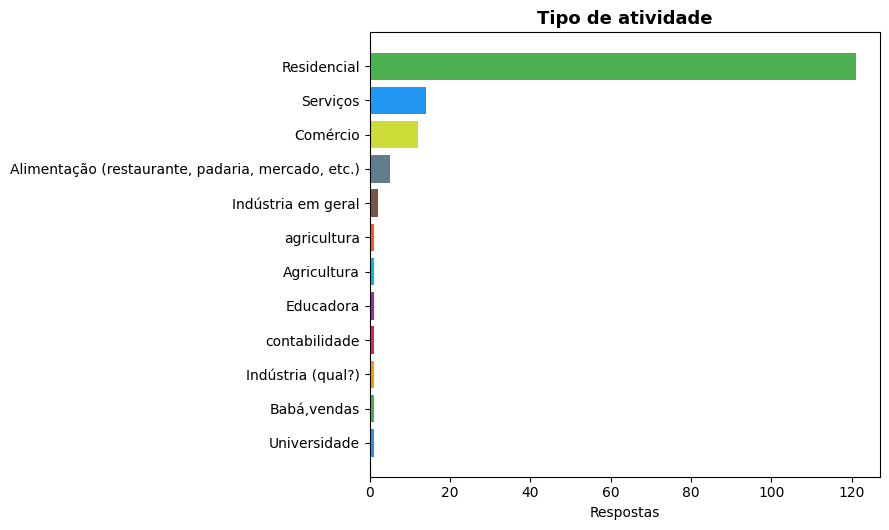

In [4]:
plotar_barras(df["tipo_atividade"].value_counts(), "Tipo de atividade", "Respostas")

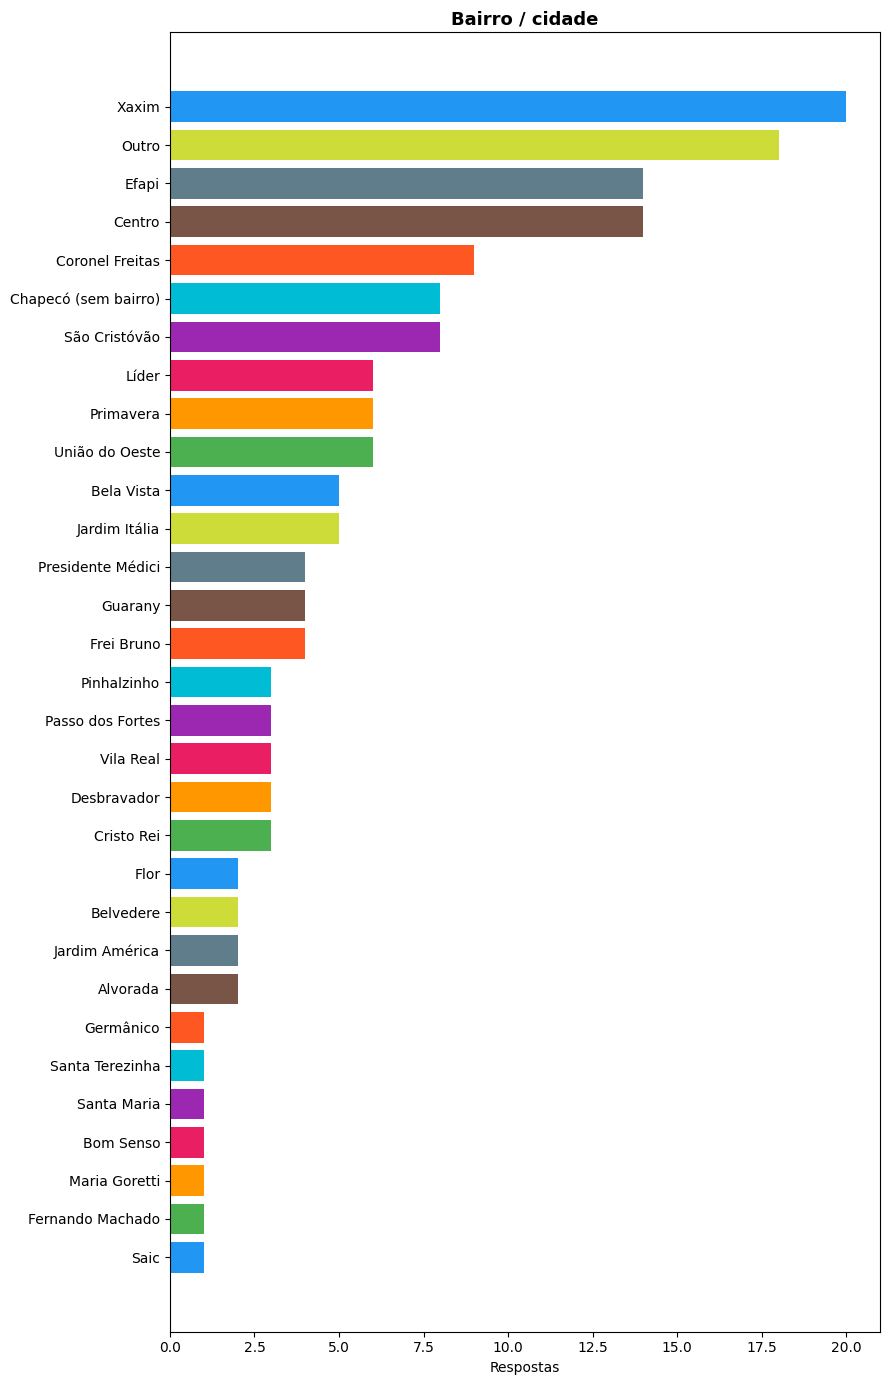

In [5]:
plotar_barras(df["bairro_cidade"].value_counts(), "Bairro / cidade", "Respostas")

## 2. O que ele gera?

Composição dos resíduos: tipo principal, detalhamento dos orgânicos e origem da geração.

As duas primeiras variáveis são **multi-select**: cada respondente podia marcar até 2 ou 3 opções, por isso o total de menções supera o número de respostas.

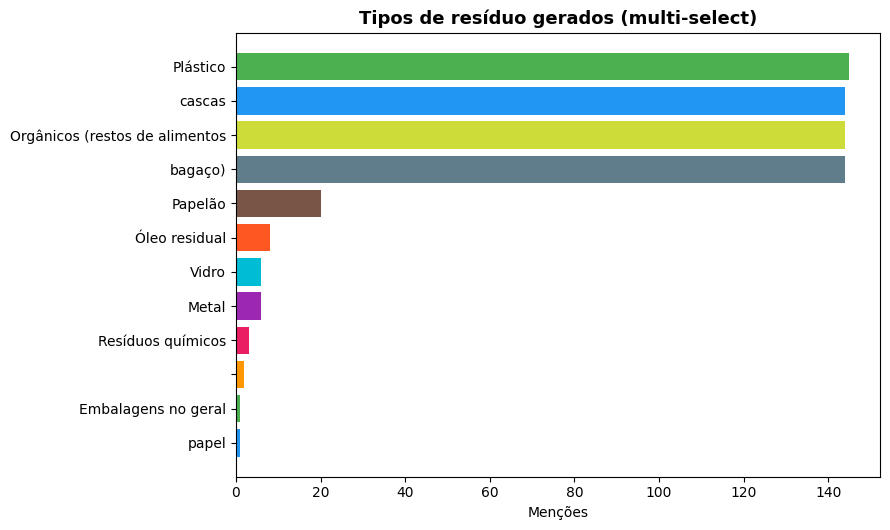

In [6]:
plotar_barras(
    contar_multiselect(df["tipos_residuo"]),
    "Tipos de resíduo gerados (multi-select)",
    "Menções",
)

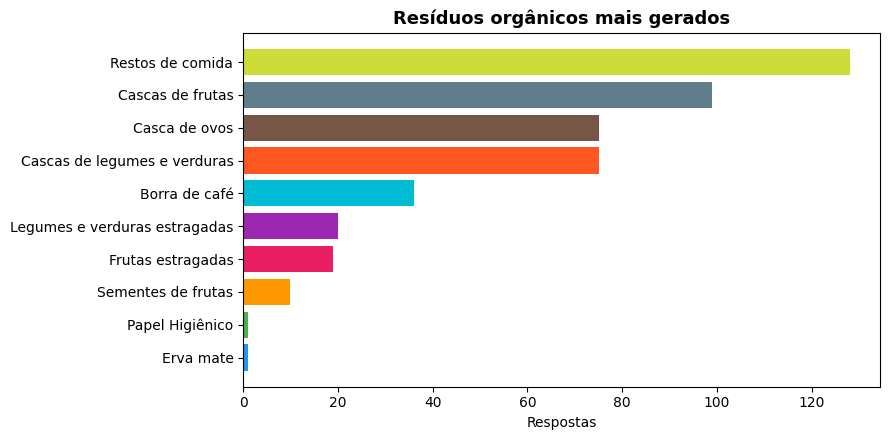

In [7]:
plotar_barras(
    contar_multiselect(df["residuos_organicos"]),
    "Resíduos orgânicos mais gerados",
    "Respostas",
    DOCS_DIR / "01_residuos_organicos.png",
)

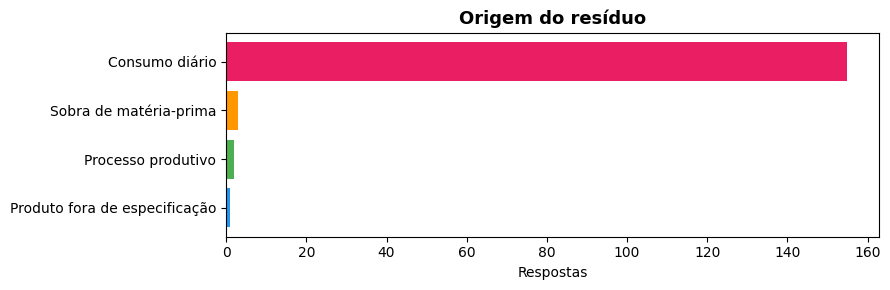

In [8]:
plotar_barras(df["origem_residuo"].value_counts(), "Origem do resíduo", "Respostas")

## 3. Quanto gera?

Volume estimado de resíduos por semana e número de pessoas no local (domicílio ou estabelecimento).

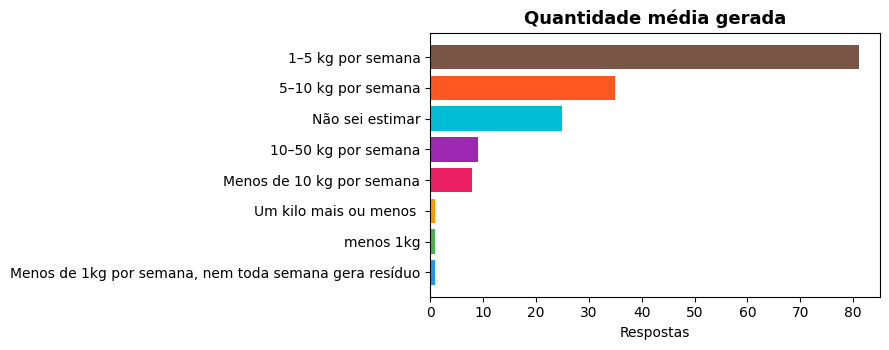

In [9]:
plotar_barras(df["quantidade_gerada"].value_counts(), "Quantidade média gerada", "Respostas")

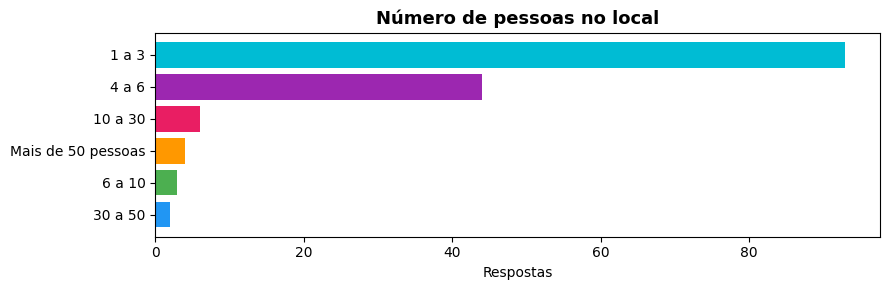

In [10]:
plotar_barras(df["num_pessoas"].value_counts(), "Número de pessoas no local", "Respostas")

## 4. O que faz com o resíduo?

Destino atual dado ao resíduo e percepção sobre custos associados à destinação.

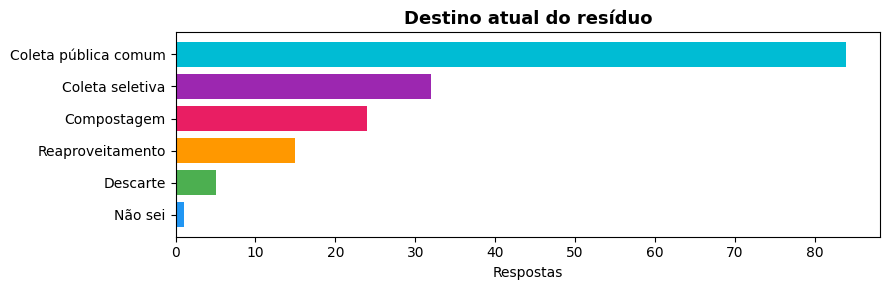

In [11]:
plotar_barras(df["destino_atual"].value_counts(), "Destino atual do resíduo", "Respostas", DOCS_DIR / "01_destino_atual.png")

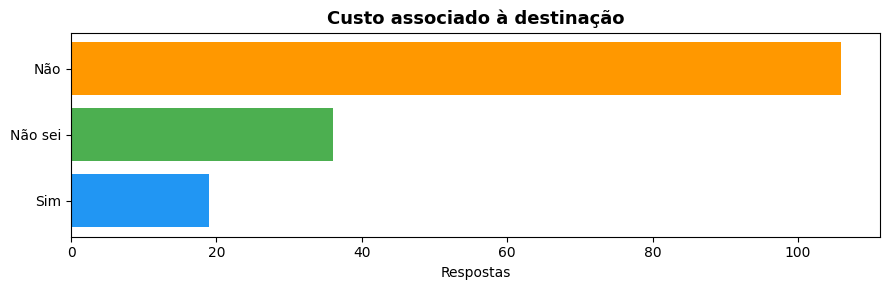

In [12]:
plotar_barras(df["custo_destinacao"].value_counts(), "Custo associado à destinação", "Respostas")

## 5. Percepção e comportamento

Autoavaliação dos respondentes sobre reaproveitamento, características percebidas dos resíduos, tentativas anteriores de reutilização e interesse em aprender.

A variável `caracteristica_residuo` é **multi-select**.

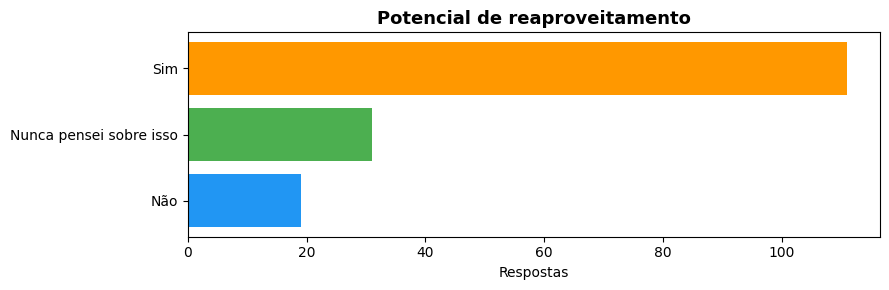

In [13]:
plotar_barras(df["potencial_reaproveitamento"].value_counts(), "Potencial de reaproveitamento", "Respostas", DOCS_DIR / "01_potencial_reaproveitamento.png")


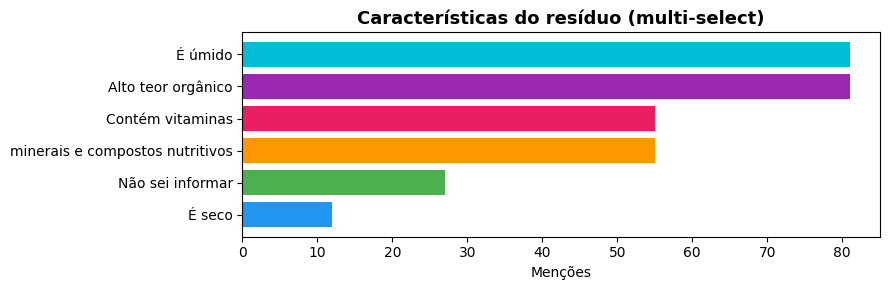

In [14]:
plotar_barras(
    contar_multiselect(df["caracteristica_residuo"]),
    "Características do resíduo (multi-select)",
    "Menções",
)

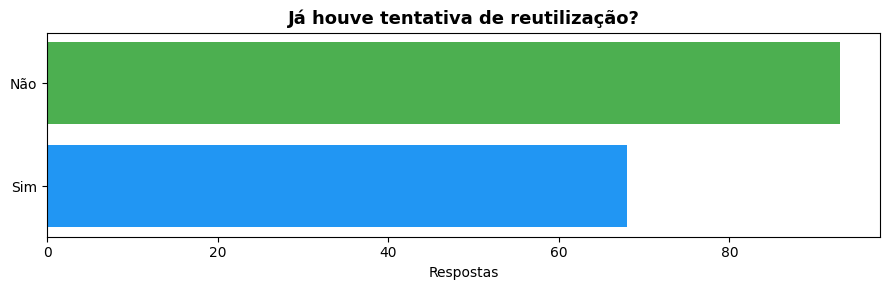

In [15]:
plotar_barras(df["tentativa_reutilizacao"].value_counts(), "Já houve tentativa de reutilização?", "Respostas")

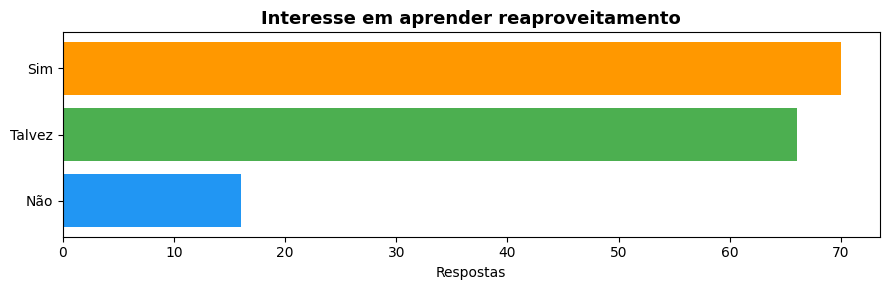

In [16]:
plotar_barras(df["interesse_aprender"].value_counts(), "Interesse em aprender reaproveitamento", "Respostas")

### Colunas excluídas desta análise

- `frequencia_descarte`: presente em apenas 9 de 161 respostas, insuficiente para análise.
- `conscientizacao`: nenhuma resposta registrada (0/161).
- `melhor_solucao` e `especificacao_residuos`: campos de texto livre, não adequados para gráficos de barras.